- 가상환경 아무거나 파고 파이썬 버전은 상관 없을 듯. 저는 3.9로 했어요
- conda create -n 4cut python=3.9 -y

- 콘다 키고
- conda activate 4cut

- 설치할 라이브러리 몇 개 없음
- pip install opencv-python pillow ultralytics

- 이제 가상환경 킨 채로, 4cut 폴더에 들어가서 실행하면 카메라 뜸
-python main_w_face.py

- pip install numpy mediapipe matplotlib scikit-learn scikit-image

- pip install --upgrade python

# 해상도 낮추고 Blur 처리 해서 space bar 로 사진찍기

# Chan code + HY code VER.

In [1]:
from PIL import Image
import numpy as np

class LayerMode:
    def __init__(self):
        return
    
    def preprocessing(self, layer, normalize=True):
        layer = self.ensure_numpy(layer)
        if normalize:
            layer = layer.astype(np.float32) / 255.0
        return layer
    
    def ensure_numpy(self, layer):
        if isinstance(layer, np.ndarray):
            return layer
        elif isinstance(layer, Image.Image):
            return np.array(layer)
        else:
            raise TypeError(f"Unsupported image type: {type(layer)}")
        
    def apply_layer(self, mode, lower_layer, upper_layer, alpha=0.5,
                    lower_normalize=True, upper_normalize=True):
        lower_layer = self.preprocessing(lower_layer, lower_normalize)
        upper_layer = self.preprocessing(upper_layer, upper_normalize)

        if mode == 'screen':
            result = self.screen(lower_layer, upper_layer, alpha)
        elif mode == 'addition':
            result = self.addition(lower_layer, upper_layer, alpha)
        elif mode == 'multiply':
            result = self.multiply(lower_layer, upper_layer, alpha)
        elif mode == 'overlay':
            result = self.overlay(lower_layer, upper_layer, alpha)
        elif mode == 'softlight':
            result = self.softlight(lower_layer, upper_layer, alpha)
        else:
            raise ValueError(f"Unknown mode: {mode}")

        result = np.clip(result, 0.0, 1.0)
        return result

    # Lighten
    def screen(self, lower_layer, upper_layer, alpha=0.5):
        inverted_lower = 1 - lower_layer
        inverted_upper = 1 - upper_layer
        out = (1 - inverted_lower * inverted_upper)
        return (1 - alpha) * lower_layer + alpha * out
    
    def addition(self, lower_layer, upper_layer, alpha=0.5):
        out = upper_layer
        return (1 - alpha) * lower_layer + alpha * out
    
    # Darken
    def multiply(self, lower_layer, upper_layer, alpha=0.5):
        out = lower_layer * upper_layer
        return (1 - alpha) * lower_layer + alpha * out
    
    # Contrast
    def overlay(self, lower_layer, upper_layer, alpha=0.5):
        out = np.zeros_like(lower_layer)
        mask = lower_layer < 0.5
        out[mask]  = lower_layer[mask] * (2 * upper_layer[mask])
        out[~mask] = 1 - 2 * (1 - lower_layer[~mask]) * (1 - upper_layer[~mask])
        return (1 - alpha) * lower_layer + alpha * out
    
    def softlight(self, lower_layer, upper_layer, alpha=0.5):
        mult = self.multiply(lower_layer, upper_layer, alpha=1)
        scrn = self.screen(lower_layer, upper_layer, alpha=1)
        out = mult * (1 - lower_layer) + scrn * lower_layer
        return (1 - alpha) * lower_layer + alpha * out


In [2]:
# ===================== 4cut Main =====================
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
import os

layer_mode = LayerMode()

# --- 유틸 ---
def apply_soft_blur_to_edges_only(img_rgba_np, feather_width=8, blur_strength=1.2):
    img_rgb = img_rgba_np[:, :, :3]
    alpha = img_rgba_np[:, :, 3]
    _, mask = cv2.threshold(alpha, 254, 255, cv2.THRESH_BINARY)
    mask = mask.astype(np.uint8)
    distance = cv2.distanceTransform(mask, distanceType=cv2.DIST_L2, maskSize=3)
    edge_mask = (distance < feather_width).astype(np.float32)
    blurred_rgb = cv2.GaussianBlur(img_rgb, (5, 5), blur_strength)
    edge_mask_3ch = np.repeat(edge_mask[:, :, np.newaxis], 3, axis=2)
    blended_rgb = (blurred_rgb * edge_mask_3ch + img_rgb * (1 - edge_mask_3ch)).astype(np.uint8)
    result = np.dstack((blended_rgb, alpha)).astype(np.uint8)
    return result

def get_next_filename(side="unknown", prefix="snapshot_", ext="png"):
    i = 1
    while os.path.exists(f"{prefix}{side}_{i:03d}.{ext}"):
        i += 1
    return f"{prefix}{side}_{i:03d}.{ext}"

def extract_background_color(frame, length_x=10, y=10, band_height=3):
    """프레임 중앙의 가로 스트립 평균색(BGR) → RGB 튜플로 반환"""
    h, w, _ = frame.shape
    y0 = max(0, y)
    y1 = min(h, y + band_height)
    x0 = max(0, w // 2 - length_x)
    x1 = min(w, w // 2 + length_x)
    extracted = frame[y0:y1, x0:x1]
    if extracted.size == 0:
        return (128, 128, 128)
    avg_bgr = np.mean(extracted, axis=(0, 1))
    return (int(avg_bgr[2]), int(avg_bgr[1]), int(avg_bgr[0]))  # to RGB

def make_colored_image(layer_mode_obj, layer_pair, reference_image_rgba):
    """
    reference_image_rgba: PIL RGBA
    layer_pair: list of (color_RGB_tuple, mode_str, alpha_float)
    - 입력은 0~255 유지, apply_layer()에서만 정규화 수행(lower/upper_normalize=True)
    """
    ref_np = np.array(reference_image_rgba)
    RGB_image = ref_np[:, :, :3]            # uint8 (0~255)
    alpha_channel = ref_np[:, :, 3]         # uint8

    h, w = RGB_image.shape[:2]
    colored = RGB_image
    for (rgb, mode, a) in layer_pair:
        color_np = np.full((h, w, 3), rgb, dtype=np.uint8)
        colored = layer_mode_obj.apply_layer(
            mode, colored, color_np, alpha=a,
            lower_normalize=True, upper_normalize=True
        )
        # colored는 0~1 float로 반환됨
        colored = (np.clip(colored, 0, 1) * 255).astype(np.uint8)

    out_rgba = np.dstack((colored, alpha_channel))
    return out_rgba


# --- 설정 ---
CELEB_IMG_PATH = r"C:\Users\chand\OneDrive\Desktop\KHUDA\LSNK6thCV\4cut\4cut\karina-removebg-preview.png"
YOLO_FACE_MODEL_PATH = r"C:\Users\chand\OneDrive\Desktop\KHUDA\LSNK6thCV\4cut\4cut\model.pt"

TARGET_CLASS = 0
LOWRES_FACTOR = 0.97
BACKGROUND_STRIP_X = 10
BACKGROUND_STRIP_Y = 10
BACKGROUND_STRIP_HEIGHT = 3  # 노이즈 완화용으로 3픽셀 높이 샘플

# --- 모델 로드 ---
model = YOLO(YOLO_FACE_MODEL_PATH)

# --- 필터 로드 & YOLO로 필터 얼굴 높이 측정 ---
celeb_img_base = Image.open(CELEB_IMG_PATH).convert("RGBA").transpose(Image.FLIP_LEFT_RIGHT)
_celeb_rgb_for_detect = celeb_img_base.convert("RGB")
_filter_det = model(np.array(_celeb_rgb_for_detect))[0]
_face_boxes = [b for b in _filter_det.boxes.data.tolist() if int(b[5]) == TARGET_CLASS]
if not _face_boxes:
    raise ValueError("연예인 필터 이미지에서 얼굴을 감지하지 못했습니다.")
filter_x1, filter_y1, filter_x2, filter_y2, *_ = map(int, _face_boxes[0])
filter_face_height = max(1, filter_y2 - filter_y1)

# --- 웹캠 ---
cap = cv2.VideoCapture(0)

# 배경색 기반 색보정은 최초 1회만
trigger_coloring_done = False
colored_celeb_img = celeb_img_base

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    h, w, _ = frame.shape

    # 최초 1회: 배경색 추출 → 필터 색 보정
    if not trigger_coloring_done:
        bg_rgb = extract_background_color(frame, length_x=BACKGROUND_STRIP_X,
                                          y=BACKGROUND_STRIP_Y, band_height=BACKGROUND_STRIP_HEIGHT)
        
        #############################  Alpha값 수정  ###################################
        # 너무 어두우면 overlay/softlight도 고려 가능. 우선 multiply 0.15 유지.
        pair = [(bg_rgb, 'multiply', 0.15)]
        colored_rgba_np = make_colored_image(layer_mode, pair, celeb_img_base)
        colored_celeb_img = Image.fromarray(colored_rgba_np, mode="RGBA")
        # colored_celeb_img.save('check_colored_filter.png')  # 디버그용
        trigger_coloring_done = True

    # 사용자 얼굴 검출
    result = model(frame, verbose=False)[0]
    face_boxes = [b for b in result.boxes.data.tolist() if int(b[5]) == TARGET_CLASS]

    if not face_boxes:
        cv2.imshow("4cut", frame)
        key = cv2.waitKey(1)
        if key == ord('q'):
            break
        elif key == 32:
            filename = get_next_filename(side="none")
            cv2.imwrite(filename, frame)
            print(f"저장됨: {filename}")
        continue

    # 가장 큰 얼굴
    x1, y1, x2, y2, *_ = map(int, max(face_boxes, key=lambda b: (b[2]-b[0]) * (b[3]-b[1])))
    cx = (x1 + x2) // 2
    user_face_height = max(1, y2 - y1)

    # 방향 판단
    if cx < w // 2:
        celeb_side = "right"
        flip = True
    else:
        celeb_side = "left"
        flip = False

    # 스케일 계산 → 리사이즈
    target_filter_height = user_face_height * 0.8
    scale = (target_filter_height / filter_face_height) * 1.3
    scale = float(np.clip(scale, 0.2, 2.0))

    scaled_width  = max(1, int(colored_celeb_img.width  * scale))
    scaled_height = max(1, int(colored_celeb_img.height * scale))
    celeb_img_resized = colored_celeb_img.resize((scaled_width, scaled_height), resample=Image.LANCZOS)
    if flip:
        celeb_img_resized = celeb_img_resized.transpose(Image.FLIP_LEFT_RIGHT)

    # 저해상도 업샘플 효과
    celeb_np = np.array(celeb_img_resized)
    low_w = max(1, int(celeb_np.shape[1] * LOWRES_FACTOR))
    low_h = max(1, int(celeb_np.shape[0] * LOWRES_FACTOR))
    lowres = cv2.resize(celeb_np, (low_w, low_h), interpolation=cv2.INTER_AREA)
    celeb_np = cv2.resize(lowres, (celeb_np.shape[1], celeb_np.shape[0]), interpolation=cv2.INTER_NEAREST)

    # 가장자리 부드럽게
    celeb_np = apply_soft_blur_to_edges_only(celeb_np, feather_width=8, blur_strength=1.8)
    celeb_img_final = Image.fromarray(celeb_np)

    # 위치 계산 (필터 얼굴 중심을 사용자 얼굴 중심에 정렬)
    pos_x = 10 if celeb_side == "left" else w - celeb_img_final.width - 10
    user_face_cy = (y1 + y2) // 2
    filter_face_cy_raw = (filter_y1 + filter_y2) // 2
    filter_face_cy_resized = int(filter_face_cy_raw * scale)
    pos_y = user_face_cy - filter_face_cy_resized

    # 합성
    frame_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)).convert("RGBA")
    frame_pil.alpha_composite(celeb_img_final, dest=(pos_x, pos_y))
    frame = cv2.cvtColor(np.array(frame_pil), cv2.COLOR_RGBA2BGR)

    # 시각화 / 저장
    cv2.imshow("4cut", frame)
    key = cv2.waitKey(1)
    if key == ord('q'):
        break
    elif key == 32:
        save_side = "left" if celeb_side == "right" else "right"
        filename = get_next_filename(side=save_side)
        cv2.imwrite(filename, frame)
        print(f"저장됨: {filename}")

cap.release()
cv2.destroyAllWindows()


0: 640x512 1 FACE, 139.9ms
Speed: 2.3ms preprocess, 139.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 512)


C:\Users\chand\AppData\Local\Temp\ipykernel_11328\3218477557.py:115: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  colored_celeb_img = Image.fromarray(colored_rgba_np, mode="RGBA")


저장됨: snapshot_left_001.png


In [4]:
import os
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from PIL import Image
from skimage.exposure import match_histograms
from sklearn.cluster import KMeans

# 사진에 따라 바로 LEFT RIGHT 전환되게끔!!

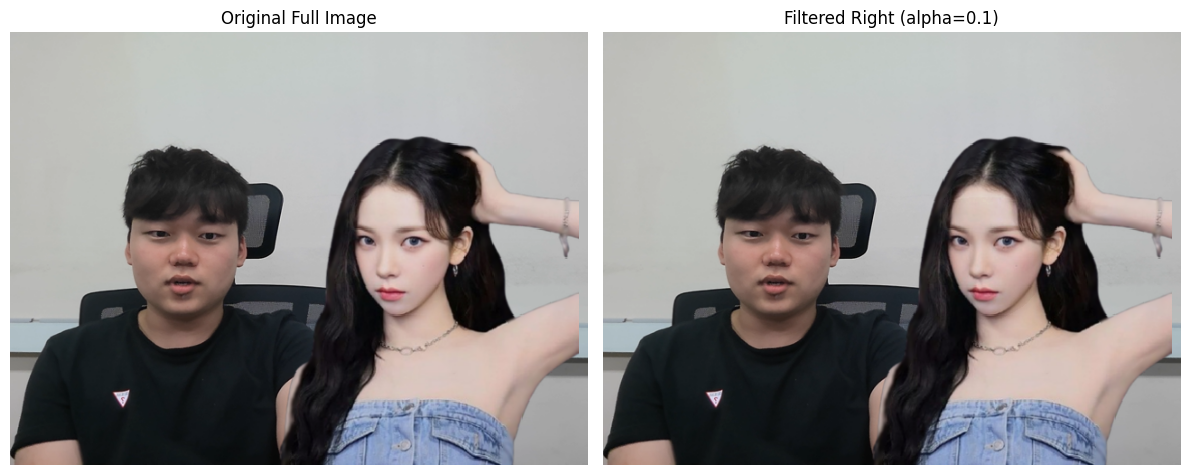

In [ ]:
# ✅ 경로 설정
img_path = r"C:\Users\chand\OneDrive\Desktop\KHUDA\LSNK6thCV\snapshot_left_001.png"  

##################
# 🔧 필터 강도 설정
alpha_left = 0.1
alpha_right = 0.1

# 1. 이미지 로드 및 분할
img = Image.open(img_path).convert("RGB")
img_rgb = np.array(img).astype(np.uint8)
h, w, _ = img_rgb.shape
left_img = img_rgb[:, :w // 2]
right_img = img_rgb[:, w // 2:]

# 2. MediaPipe 설정
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=2, refine_landmarks=True)

# 3. 얼굴 마스크 함수
def get_face_mask(img, is_left=True):
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    results = face_mesh.process(img)
    if results.multi_face_landmarks:
        centers = [np.mean([lm.x * img.shape[1] for lm in f.landmark]) for f in results.multi_face_landmarks]
        idx = np.argmin(centers) if is_left else np.argmax(centers)
        face = results.multi_face_landmarks[idx]
        points = np.array([[int(lm.x * img.shape[1]), int(lm.y * img.shape[0])] for lm in face.landmark])
        hull = cv2.convexHull(points)
        cv2.fillConvexPoly(mask, hull, 255)
    return mask

# 4. 마스크 확장 함수
def expand_face_mask_by_color_similarity(img, mask, threshold=40, dilate_iter=5):
    kernel = np.ones((3, 3), np.uint8)
    mean_color = cv2.mean(img, mask=mask)[:3]
    base_color_img = np.full_like(img, mean_color, dtype=np.uint8)
    dilated = cv2.dilate(mask, kernel, iterations=dilate_iter)
    diff = np.abs(img.astype(np.int16) - base_color_img.astype(np.int16))
    diff_mean = diff.mean(axis=2)
    new_mask = ((diff_mean < threshold) & (dilated > 0)).astype(np.uint8) * 255
    return new_mask

# 5. 공통 전처리
left_face_mask = get_face_mask(left_img, is_left=True)
right_face_mask = get_face_mask(right_img, is_left=False)

# 🔁 조건 분기
if "left" in os.path.basename(img_path).lower():
    # ✅ 'left' → 오른쪽 인물에 필터 적용
    alpha = alpha_right
    target_img = right_img
    reference_img = left_img
    target_mask = expand_face_mask_by_color_similarity(target_img, right_face_mask, threshold=70, dilate_iter=5)
    target_mask = cv2.GaussianBlur(target_mask, (11, 11), 0)

    # 얼굴 추출
    ref_face_only = reference_img.copy()
    ref_face_only[left_face_mask == 0] = 0
    tgt_face_only = target_img.copy()
    tgt_face_only[target_mask == 0] = 0

    # 히스토그램 매칭
    matched_face = match_histograms(tgt_face_only, ref_face_only, channel_axis=-1)

    # 머리카락 탐지
    masked_pixels = target_img[target_mask > 100].reshape(-1, 3)
    kmeans = KMeans(n_clusters=8, random_state=42).fit(masked_pixels)
    labels = kmeans.predict(target_img.reshape(-1, 3)).reshape(target_img.shape[:2])

    hair_mask = np.zeros(target_img.shape[:2], dtype=bool)
    for i in range(8):
        rgb = np.mean(masked_pixels[kmeans.labels_ == i], axis=0)
        hsv = cv2.cvtColor(np.uint8([[rgb]]), cv2.COLOR_RGB2HSV)[0][0]
        h, s, v = hsv
        if ((10 < h < 35 and s > 40 and v > 40) or (s < 50 and v < 70)):
            hair_mask |= (labels == i)

    gray_img = cv2.cvtColor(target_img, cv2.COLOR_RGB2GRAY)
    bright_skin_mask = (gray_img > 150)
    hair_mask = hair_mask & (~bright_skin_mask)

    final_mask = cv2.bitwise_and(target_mask, 255 - hair_mask.astype(np.uint8) * 255)
    final_mask = cv2.GaussianBlur(final_mask, (9, 9), 0)

    filtered_target = target_img.copy()
    for c in range(3):
        blended = (
            alpha * matched_face[:, :, c] + (1 - alpha) * target_img[:, :, c]
        ).astype(np.uint8)
        filtered_target[:, :, c][final_mask > 100] = blended[final_mask > 100]

    filtered_target[hair_mask] = target_img[hair_mask]

    # 병합
    result_full = np.concatenate((reference_img, filtered_target), axis=1)

else:
    # ✅ 'right' → 왼쪽 인물에 필터 적용
    alpha = alpha_left
    target_img = left_img
    reference_img = right_img
    target_mask = expand_face_mask_by_color_similarity(target_img, left_face_mask, threshold=70, dilate_iter=5)
    target_mask = cv2.GaussianBlur(target_mask, (11, 11), 0)

    ref_face_only = reference_img.copy()
    ref_face_only[right_face_mask == 0] = 0
    tgt_face_only = target_img.copy()
    tgt_face_only[target_mask == 0] = 0

    matched_face = match_histograms(tgt_face_only, ref_face_only, channel_axis=-1)

    masked_pixels = target_img[target_mask > 100].reshape(-1, 3)
    kmeans = KMeans(n_clusters=8, random_state=42).fit(masked_pixels)
    labels = kmeans.predict(target_img.reshape(-1, 3)).reshape(target_img.shape[:2])

    hair_mask = np.zeros(target_img.shape[:2], dtype=bool)
    for i in range(8):
        rgb = np.mean(masked_pixels[kmeans.labels_ == i], axis=0)
        hsv = cv2.cvtColor(np.uint8([[rgb]]), cv2.COLOR_RGB2HSV)[0][0]
        h, s, v = hsv
        if ((10 < h < 35 and s > 40 and v > 40) or (s < 50 and v < 70)):
            hair_mask |= (labels == i)

    gray_img = cv2.cvtColor(target_img, cv2.COLOR_RGB2GRAY)
    bright_skin_mask = (gray_img > 150)
    hair_mask = hair_mask & (~bright_skin_mask)

    final_mask = cv2.bitwise_and(target_mask, 255 - hair_mask.astype(np.uint8) * 255)
    final_mask = cv2.GaussianBlur(final_mask, (9, 9), 0)

    filtered_target = target_img.copy()
    for c in range(3):
        blended = (
            alpha * matched_face[:, :, c] + (1 - alpha) * target_img[:, :, c]
        ).astype(np.uint8)
        filtered_target[:, :, c][final_mask > 100] = blended[final_mask > 100]

    filtered_target[hair_mask] = target_img[hair_mask]

    # 병합
    result_full = np.concatenate((filtered_target, reference_img), axis=1)

# ✅ 시각화
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Full Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_full)
plt.title(f"Filtered {'Right' if 'left' in os.path.basename(img_path).lower() else 'Left'} (alpha={alpha})")
plt.axis('off')
plt.tight_layout()
plt.show()